In [72]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sklearn as sk
from scipy.optimize import minimize
from matplotlib.ticker import AutoMinorLocator

In [73]:

# s = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])

# noise_test = np.array(pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\original-database\ruido_ocup80.csv', header=None))
# resultado = np.random.exponential(scale=1, size=(100000, 1))
# r = np.ones((noise_test.shape[0], noise_test.shape[1]))
# r
# for i in range(100000):
#     r[i] = resultado[i]*s + noise_test[i]

# dados = pd.DataFrame(r)
# dados['AmplitudeSample(4)'] = resultado
# dados.to_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_ocup80_sarita.csv', index=False)

In [74]:
#Save 

save = { #Se quiser salvar os resultados, basta colocar True
    'Nelder_mead': True, 
    'Rede_Neural': True,
}

In [75]:

data = [pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_2.csv'),
        pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_5.csv'),
        pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_7.csv'),
        pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_9.csv'),]

columns = data[0].columns # salva os nomes das colunas
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']

In [76]:
def collect_stats(result, df):
    residual = np.array(result) - np.array(df)
    mean = np.mean(residual)
    std = np.std(residual)
    return residual, mean, std

def save_stats(name, residual, mean, std, occ):
    residuals_path = f'.\\results\\{name}_residuals.csv'
    stats_path = f'.\\results\\{name}_stats.csv'

    # Carrega residuais existentes ou cria DataFrame vazio
    if os.path.exists(residuals_path):
        residuals_df = pd.read_csv(residuals_path)
    else:
        residuals_df = pd.DataFrame()

    # Carrega stats existentes ou cria DataFrame vazio
    if os.path.exists(stats_path):
        stats_df = pd.read_csv(stats_path)
    else:
        stats_df = pd.DataFrame(columns=['occupancy', 'mean', 'std'])

    # Adiciona nova coluna de resíduos e nova linha de stats
    residuals_df[f'{occ}'] = residual
    stats_df = pd.concat(
        [stats_df, pd.DataFrame({'occupancy': [occ], 'mean': [mean], 'std': [std]})],
        ignore_index=True
    )

    # Salva no disco
    residuals_df.to_csv(residuals_path, index=False)
    stats_df.to_csv(stats_path, index=False)

def load_results():
    nm_residuals = pd.read_csv('.\\results\\nm_residuals.csv', index_col=False)
    nm_stats = pd.read_csv('.\\results\\nm_stats.csv', index_col=False)
    rn_residuals = pd.read_csv('.\\results\\rn_residuals.csv', index_col=False)
    rn_stats = pd.read_csv('.\\results\\rn_stats.csv', index_col=False)

    return nm_residuals, nm_stats, rn_residuals, rn_stats
   

In [77]:
#Rede Neural
def run_model(X, y):
    def build_model():
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(21, activation='tanh', input_shape=(X.shape[1],)),
            tf.keras.layers.Dense(14, activation='tanh'),
            tf.keras.layers.Dense(7, activation='tanh'),
            tf.keras.layers.Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        return model

    model = build_model()
    history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=2)
    res = model.predict(X)
    return res.flatten()

#Método de Nelder-Mead
def nelderMead(df):

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    sample4 = []

    for samples in df:
        sample4.append((minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': 1e-2}).x)[3])
        print(f'Sample {len(sample4)} done')

    return sample4

In [78]:
def reset_save():
    if save['Nelder_mead']:
        if os.path.exists('.\\results\\nm_residuals.csv'):
            os.remove('.\\results\\nm_residuals.csv')
        if os.path.exists('.\\results\\nm_stats.csv'):
            os.remove('.\\results\\nm_stats.csv')

    if save['Rede_Neural']:
        if os.path.exists('.\\results\\rn_residuals.csv'):
            os.remove('.\\results\\rn_residuals.csv')
        if os.path.exists('.\\results\\rn_stats.csv'):
            os.remove('.\\results\\rn_stats.csv')

In [ ]:
def run_algorithm(data):

    reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    
    for i in range(len(data)):

        samples_data = np.array(data[i][columns[0:7]])
        amplitudes_data = np.array(data[i][columns[7]])

        if save['Nelder_mead']==True:
            sample4 = nelderMead(samples_data)
            residual, mean, std = collect_stats(sample4, amplitudes_data)
            save_stats('nm', residual, mean, std, occ_name[i])
            
        if save['Rede_Neural']==True:
            res = run_model(samples_data, amplitudes_data)
            residual, mean, std = collect_stats(res, amplitudes_data)
            save_stats('rn', residual, mean, std, occ_name[i])

 

In [ ]:
#Roda o codigo 
run_algorithm(data)

Sample 1 done
Sample 2 done
Sample 3 done
Sample 4 done
Sample 5 done
Sample 6 done
Sample 7 done
Sample 8 done
Sample 9 done
Sample 10 done
Sample 11 done
Sample 12 done
Sample 13 done
Sample 14 done
Sample 15 done
Sample 16 done
Sample 17 done
Sample 18 done
Sample 19 done
Sample 20 done
Sample 21 done
Sample 22 done
Sample 23 done
Sample 24 done
Sample 25 done
Sample 26 done
Sample 27 done
Sample 28 done
Sample 29 done
Sample 30 done
Sample 31 done
Sample 32 done
Sample 33 done
Sample 34 done
Sample 35 done
Sample 36 done
Sample 37 done
Sample 38 done
Sample 39 done
Sample 40 done
Sample 41 done
Sample 42 done
Sample 43 done
Sample 44 done
Sample 45 done
Sample 46 done
Sample 47 done
Sample 48 done
Sample 49 done
Sample 50 done
Sample 51 done
Sample 52 done
Sample 53 done
Sample 54 done
Sample 55 done
Sample 56 done
Sample 57 done
Sample 58 done
Sample 59 done
Sample 60 done
Sample 61 done
Sample 62 done
Sample 63 done
Sample 64 done
Sample 65 done
Sample 66 done
Sample 67 done
Samp

KeyboardInterrupt: 

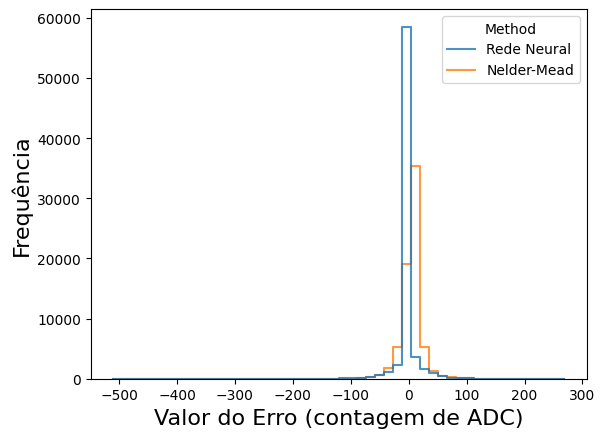

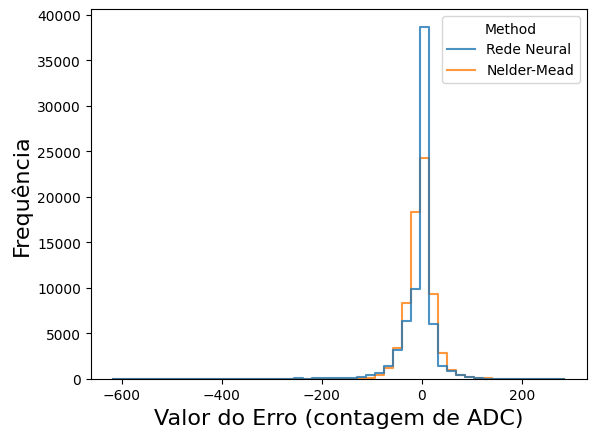

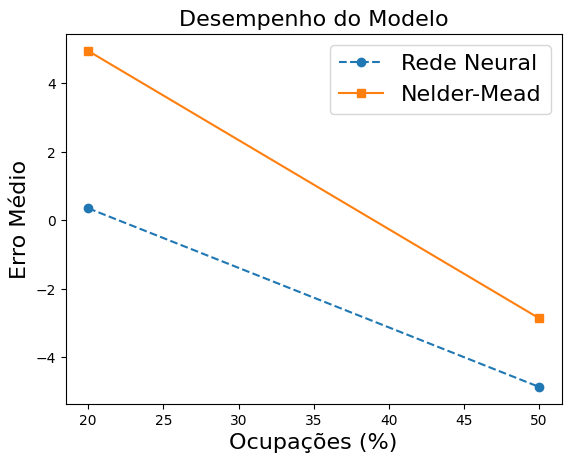

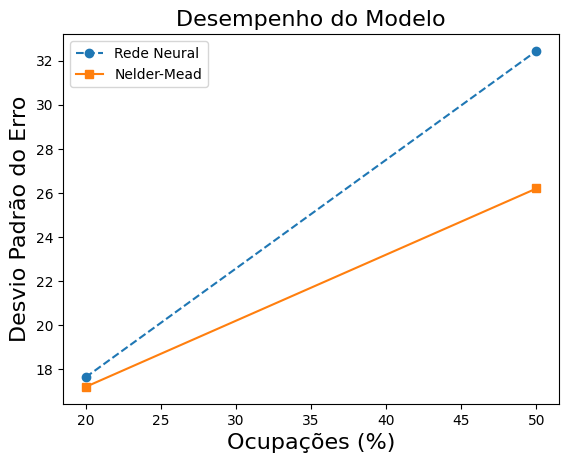

In [ ]:
#Visualização dos resultados  


nm_residuals, nm_stats, rn_residuals, rn_stats = load_results()
fsize = 16

palette = [
    "#1f77b4",  # Rede Neural
    "#ff7f0e",  # Nelder-Mead
]

#Distribuição dos resíduos
for idx, occ in enumerate([occ_name]):
    results = pd.concat([
            pd.DataFrame({"Residual Value": rn_residuals[occ], "Method": f"Rede Neural"}),
            pd.DataFrame({"Residual Value": nm_residuals[occ], "Method": f"Nelder-Mead"}),
        ])
    sns.histplot(data=results, hue="Method", legend=True, x="Residual Value", bins=50, fill=False, element="step", palette=palette, alpha=0.8)
    plt.ylabel("Frequência", fontsize=fsize)
    plt.xlabel("Valor do Erro (contagem de ADC)", fontsize=fsize)
    plt.show()

occ = [20, 50, 70, 90]

#Graficos de Média e Desvio Padrão
plt.plot(occ, rn_stats['mean'], marker='o', color=palette[0], label='Rede Neural', linestyle='--')
plt.plot(occ, nm_stats['mean'], marker='s', color=palette[1], label='Nelder-Mead')
plt.xlabel('Ocupações (%)', fontsize=fsize)
plt.ylabel('Erro Médio', fontsize=fsize)
plt.title('Desempenho do Modelo', fontsize=fsize)
plt.legend(fontsize=fsize)
plt.show()

plt.plot(occ, rn_stats['std'], marker='o', color=palette[0], label='Rede Neural', linestyle='--')
plt.plot(occ, nm_stats['std'], marker='s', color=palette[1], label='Nelder-Mead')
plt.xlabel('Ocupações (%)', fontsize=fsize)
plt.ylabel('Desvio Padrão do Erro', fontsize=fsize)
plt.title('Desempenho do Modelo', fontsize=fsize)
plt.legend()
plt.show()